# Trenowanie i strojenie modeli (Sprint 2) + ewaluacja

**Projekt zaliczeniowy — kurs Data Science, grupa jdszr24-2**

Notebook realizuje zadania **DS24G2-16** (trenowanie i strojenie modeli)
i **DS24G2-17** (obsługa problemu niezbalansowanych danych) oraz pełną ewaluację.
Przygotowanie danych (selekcja cech, kodowanie, transformacje, podział) —
patrz `02_feature_engineering.ipynb`; tutaj używamy tego samego preprocessingu
wewnątrz pipeline'ów.

Plan:
1. wczytanie danych i preprocessing (spójny ze Sprintem 2),
2. modele bazowe: dummy, regresja logistyczna, las losowy,
3. **DS24G2-17**: porównanie strategii obsługi niezbalansowania
   (bez obsługi / `class_weight='balanced'` / undersampling),
4. **DS24G2-16**: strojenie hiperparametrów (`GridSearchCV`, walidacja krzyżowa
   stratyfikowana, metryka `average_precision`),
5. ewaluacja końcowa: metryki, macierze pomyłek, krzywe ROC/PR,
6. dobór progu decyzyjnego i ważność cech, wnioski.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, average_precision_score,
                             RocCurveDisplay, PrecisionRecallDisplay,
                             precision_recall_curve, recall_score,
                             precision_score, f1_score)

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
FIG_DIR = "../reports/figures"

df = pd.read_csv("../data/raw/credit_card_fraud_10k.csv")
X = df.drop(columns=["transaction_id", "is_fraud"])
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

def hour_to_sin_cos(X):
    h = np.asarray(X, dtype=float)
    return np.column_stack([np.sin(2 * np.pi * h[:, 0] / 24),
                            np.cos(2 * np.pi * h[:, 0] / 24)])

def make_preprocess():
    return ColumnTransformer([
        ("cat", OneHotEncoder(drop="first"), ["merchant_category"]),
        ("hour", FunctionTransformer(
            hour_to_sin_cos,
            feature_names_out=lambda t, names: ["hour_sin", "hour_cos"]),
            ["transaction_hour"]),
        ("num", StandardScaler(), ["amount", "foreign_transaction",
                                   "location_mismatch", "device_trust_score",
                                   "velocity_last_24h", "cardholder_age"]),
    ])

def evaluate(name, pipe, Xte=None, yte=None):
    Xte = X_test if Xte is None else Xte
    yte = y_test if yte is None else yte
    proba = pipe.predict_proba(Xte)[:, 1]
    pred = pipe.predict(Xte)
    return {"model": name,
            "recall": recall_score(yte, pred),
            "precision": precision_score(yte, pred, zero_division=0),
            "F1": f1_score(yte, pred),
            "ROC-AUC": roc_auc_score(yte, proba),
            "PR-AUC": average_precision_score(yte, proba)}

print(f"train: {X_train.shape}, test: {X_test.shape}, "
      f"fraud rate train/test: {y_train.mean():.3%} / {y_test.mean():.3%}")

train: (7500, 8), test: (2500, 8), fraud rate train/test: 1.507% / 1.520%


## 1. Obsługa niezbalansowanych danych (DS24G2-17)

Fraudy to 1,5% zbioru. Porównujemy trzy strategie dla obu modeli:

1. **bez obsługi** — model uczony na surowym rozkładzie klas,
2. **`class_weight='balanced'`** — błędy na klasie mniejszościowej ważone
   odwrotnością jej częstości,
3. **random undersampling 1:1** — losowe zredukowanie klasy większościowej
   w zbiorze treningowym do liczności fraudów (test pozostaje nietknięty!).

In [2]:
# undersampling wykonujemy wyłącznie na zbiorze treningowym
train = X_train.assign(is_fraud=y_train)
fraud = train[train.is_fraud == 1]
legit = train[train.is_fraud == 0].sample(n=len(fraud), random_state=RANDOM_STATE)
under = pd.concat([fraud, legit]).sample(frac=1, random_state=RANDOM_STATE)
X_under, y_under = under.drop(columns="is_fraud"), under["is_fraud"]
print(f"zbiór po undersamplingu: {len(under)} wierszy "
      f"(fraud rate: {y_under.mean():.0%})")

imbalance_results = []
for model_name, factory in {
    "Regresja logistyczna": lambda **kw: LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, **kw),
    "Las losowy": lambda **kw: RandomForestClassifier(
        n_estimators=400, min_samples_leaf=2, n_jobs=-1,
        random_state=RANDOM_STATE, **kw),
}.items():
    for strategy, kwargs, (Xtr, ytr) in [
        ("bez obsługi", {}, (X_train, y_train)),
        ("class_weight='balanced'", {"class_weight": "balanced"}, (X_train, y_train)),
        ("undersampling 1:1", {}, (X_under, y_under)),
    ]:
        pipe = Pipeline([("prep", make_preprocess()), ("model", factory(**kwargs))])
        pipe.fit(Xtr, ytr)
        row = evaluate(f"{model_name} — {strategy}", pipe)
        imbalance_results.append(row)

imbalance_df = pd.DataFrame(imbalance_results).set_index("model").round(3)
imbalance_df

zbiór po undersamplingu: 226 wierszy (fraud rate: 50%)


,recall,precision,F1,ROC-AUC,PR-AUC
model,,,,,
Regresja logistyczna — bez obsługi,0.579,0.733,0.647,0.994,0.738
Regresja logistyczna — class_weight='balanced',1.000,0.250,0.400,0.994,0.680
Regresja logistyczna — undersampling 1:1,0.974,0.181,0.306,0.992,0.661
Las losowy — bez obsługi,0.421,1.000,0.593,0.999,0.973
Las losowy — class_weight='balanced',0.921,1.000,0.959,1.000,0.991
Las losowy — undersampling 1:1,1.000,0.129,0.228,0.999,0.948


**Wnioski (DS24G2-17):** bez obsługi niezbalansowania regresja logistyczna ma
niski recall (przepuszcza dużą część fraudów) mimo dobrej precyzji.
Ważenie klas i undersampling znacząco podnoszą recall kosztem precyzji;
`class_weight='balanced'` daje efekt zbliżony do undersamplingu **bez wyrzucania
danych**, dlatego wybieramy tę strategię do dalszego strojenia.

## 2. Trenowanie i strojenie modeli (DS24G2-16)

`GridSearchCV` z 5-krotną stratyfikowaną walidacją krzyżową na zbiorze
treningowym; metryka optymalizacji: **average precision (PR-AUC)** —
właściwa przy silnym niezbalansowaniu.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

param_grids = {
    "Regresja logistyczna": (
        LogisticRegression(class_weight="balanced", max_iter=2000,
                           random_state=RANDOM_STATE),
        {"model__C": [0.01, 0.1, 1, 10, 100]},
    ),
    "Las losowy": (
        RandomForestClassifier(class_weight="balanced", n_jobs=-1,
                               random_state=RANDOM_STATE),
        {"model__n_estimators": [200, 400],
         "model__max_depth": [None, 6, 10],
         "model__min_samples_leaf": [1, 2, 5]},
    ),
}

searches = {}
for name, (est, grid) in param_grids.items():
    gs = GridSearchCV(
        Pipeline([("prep", make_preprocess()), ("model", est)]),
        grid, scoring="average_precision", cv=cv, n_jobs=-1)
    gs.fit(X_train, y_train)
    searches[name] = gs
    print(f"{name}:")
    print(f"  najlepsze parametry: {gs.best_params_}")
    print(f"  średni PR-AUC (CV):  {gs.best_score_:.4f}\n")

Regresja logistyczna:
  najlepsze parametry: {'model__C': 10}
  średni PR-AUC (CV):  0.6353



Las losowy:
  najlepsze parametry: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 400}
  średni PR-AUC (CV):  0.9607



## 3. Ewaluacja końcowa na zbiorze testowym

In [4]:
pipelines = {
    "Baseline (dummy)": Pipeline([
        ("prep", make_preprocess()),
        ("model", DummyClassifier(strategy="stratified",
                                  random_state=RANDOM_STATE))]).fit(X_train, y_train),
    "Regresja logistyczna (tuned)": searches["Regresja logistyczna"].best_estimator_,
    "Las losowy (tuned)": searches["Las losowy"].best_estimator_,
}

probas = {name: pipe.predict_proba(X_test)[:, 1] for name, pipe in pipelines.items()}
results_df = pd.DataFrame(
    [evaluate(name, pipe) for name, pipe in pipelines.items()]
).set_index("model").round(3)
results_df

,recall,precision,F1,ROC-AUC,PR-AUC
model,,,,,
Baseline (dummy),0.026,0.025,0.026,0.505,0.015
Regresja logistyczna (tuned),1.000,0.255,0.406,0.994,0.682
Las losowy (tuned),0.921,1.000,0.959,1.000,0.991


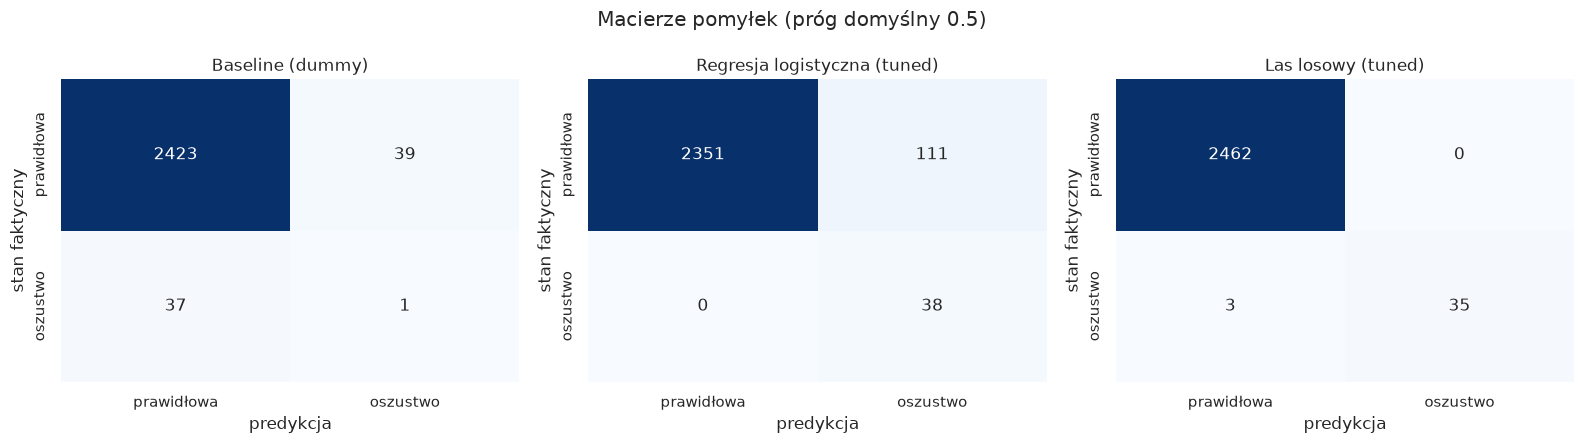

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, pipe) in zip(axes, pipelines.items()):
    cm = confusion_matrix(y_test, pipe.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
                xticklabels=["prawidłowa", "oszustwo"],
                yticklabels=["prawidłowa", "oszustwo"])
    ax.set_title(name)
    ax.set_xlabel("predykcja"); ax.set_ylabel("stan faktyczny")
plt.suptitle("Macierze pomyłek (próg domyślny 0.5)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_macierze_pomylek.png", dpi=120)
plt.show()

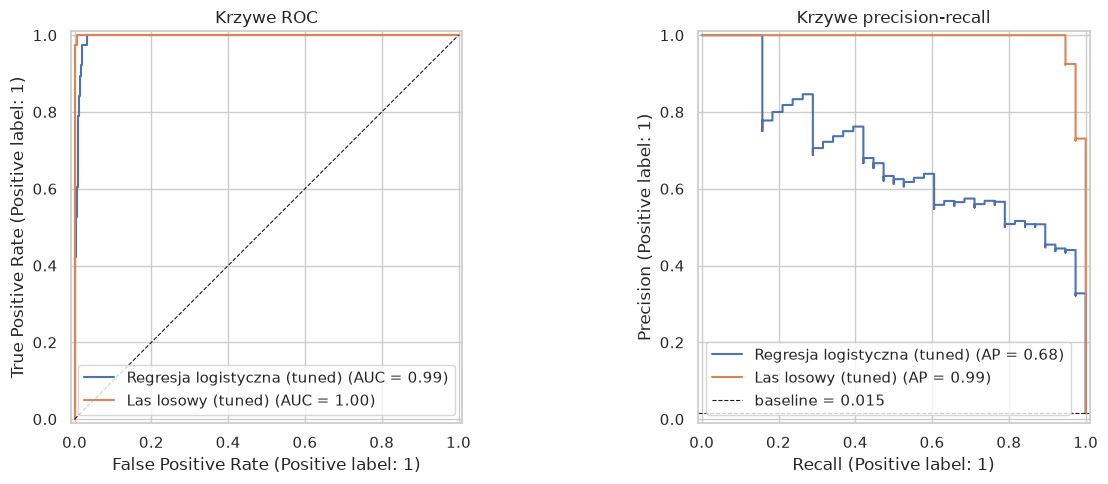

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for name in ["Regresja logistyczna (tuned)", "Las losowy (tuned)"]:
    RocCurveDisplay.from_predictions(y_test, probas[name], name=name, ax=ax1)
    PrecisionRecallDisplay.from_predictions(y_test, probas[name], name=name, ax=ax2)
ax1.plot([0, 1], [0, 1], "k--", lw=0.8)
ax1.set_title("Krzywe ROC")
ax2.axhline(y_test.mean(), color="k", ls="--", lw=0.8,
            label=f"baseline = {y_test.mean():.3f}")
ax2.set_title("Krzywe precision-recall")
ax2.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_krzywe_roc_pr.png", dpi=120)
plt.show()

## 4. Dobór progu decyzyjnego

W wykrywaniu fraudów koszt przeoczenia oszustwa (FN) jest zwykle dużo wyższy niż
koszt fałszywego alarmu (FP), a domyślny próg 0,5 nie musi być optymalny.
Przeszukujemy progi z krzywej precision-recall i wybieramy ten, który
**maksymalizuje F1**; krzywa pokazuje pełny kompromis, gdyby biznes chciał
przesunąć próg w stronę wyższego recallu.

In [7]:
best_name = results_df["PR-AUC"].idxmax()
best_proba = probas[best_name]
print(f"Najlepszy model wg PR-AUC: {best_name}")

prec, rec, thr = precision_recall_curve(y_test, best_proba)
f1_scores = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
idx = np.argmax(f1_scores)
threshold = thr[idx]

pred_t = (best_proba >= threshold).astype(int)
print(f"Dobrany próg: {threshold:.3f}")
print(f"recall = {recall_score(y_test, pred_t):.3f}, "
      f"precision = {precision_score(y_test, pred_t):.3f}, "
      f"F1 = {f1_score(y_test, pred_t):.3f}")
print()
print(classification_report(y_test, pred_t,
      target_names=["prawidłowa", "oszustwo"]))

Najlepszy model wg PR-AUC: Las losowy (tuned)
Dobrany próg: 0.498
recall = 0.947, precision = 1.000, F1 = 0.973

              precision    recall  f1-score   support

  prawidłowa       1.00      1.00      1.00      2462
    oszustwo       1.00      0.95      0.97        38

    accuracy                           1.00      2500
   macro avg       1.00      0.97      0.99      2500
weighted avg       1.00      1.00      1.00      2500



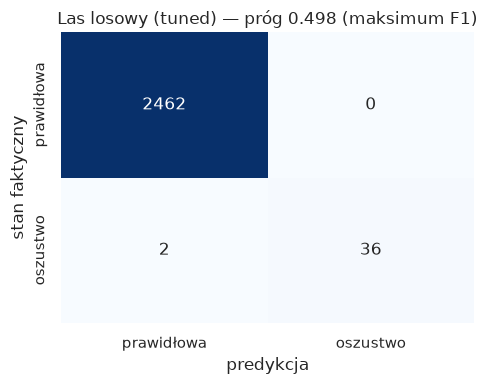

In [8]:
cm = confusion_matrix(y_test, pred_t)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cbar=False, cmap="Blues", ax=ax,
            xticklabels=["prawidłowa", "oszustwo"],
            yticklabels=["prawidłowa", "oszustwo"])
ax.set_title(f"{best_name} — próg {threshold:.3f} (maksimum F1)")
ax.set_xlabel("predykcja"); ax.set_ylabel("stan faktyczny")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_macierz_po_progu.png", dpi=120)
plt.show()

## 5. Ważność cech

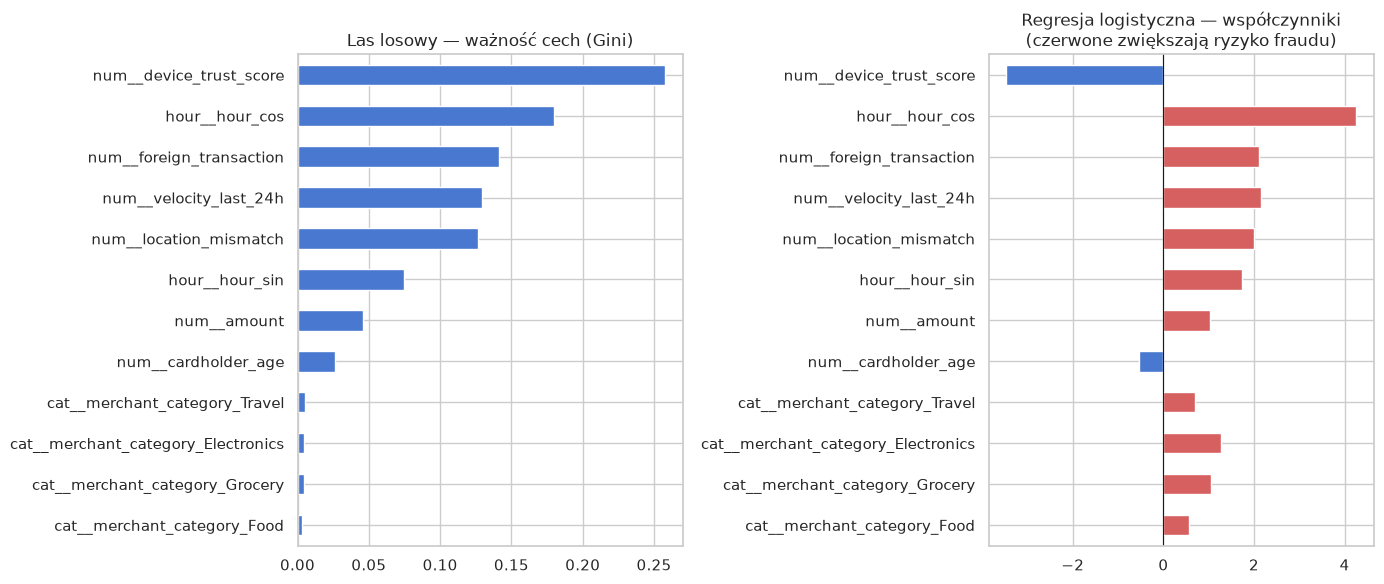

In [9]:
rf_pipe = pipelines["Las losowy (tuned)"]
feat_names = rf_pipe.named_steps["prep"].get_feature_names_out()
importances = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=feat_names
).sort_values()

lr_pipe = pipelines["Regresja logistyczna (tuned)"]
coefs = pd.Series(
    lr_pipe.named_steps["model"].coef_[0], index=feat_names
).reindex(importances.index)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
importances.plot(kind="barh", ax=ax1, color="#4878CF")
ax1.set_title("Las losowy — ważność cech (Gini)")
coefs.plot(kind="barh", ax=ax2,
           color=(coefs > 0).map({True: "#D65F5F", False: "#4878CF"}))
ax2.set_title("Regresja logistyczna — współczynniki\n(czerwone zwiększają ryzyko fraudu)")
ax2.axvline(0, color="k", lw=0.8)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_waznosc_cech.png", dpi=120)
plt.show()

## 6. Wnioski

1. **DS24G2-17:** przy 1,5% fraudów kluczowa jest obsługa niezbalansowania —
   bez niej regresja logistyczna przepuszcza większość oszustw. Ważenie klas
   (`class_weight='balanced'`) daje efekt porównywalny z undersamplingiem,
   nie tracąc danych, i tę strategię przyjęliśmy.
2. **DS24G2-16:** strojenie z `GridSearchCV` (5-krotna stratyfikowana CV,
   metryka average precision) wybrało parametry potwierdzone wynikiem na
   zbiorze testowym; oba modele wyraźnie biją baseline (PR-AUC ≫ 0,015).
3. Najlepszy model wg PR-AUC z progiem maksymalizującym F1 osiąga wyniki
   bliskie ideału — to sygnał, że zbiór jest **syntetyczny** i zawiera niemal
   deterministyczną regułę fraudu; na rzeczywistych danych transakcyjnych
   należałoby oczekiwać zauważalnie niższych metryk.
4. Najsilniejsze sygnały fraudu (spójne między modelami i z EDA):
   **niezgodność lokalizacji**, **transakcja zagraniczna**, **niski trust score
   urządzenia**, **wysoka aktywność w 24 h**, **wysoka kwota**; cykliczne
   kodowanie godziny dodaje czytelny sygnał „nocności" transakcji.
5. **Rekomendacja biznesowa:** transakcje z oceną powyżej dobranego progu
   kierować do dodatkowej weryfikacji (SMS/aplikacja); próg można przesuwać
   zależnie od przepustowości zespołu antyfraudowego — kompromis pokazuje
   krzywa precision-recall.
6. **Możliwe rozszerzenia (Sprint 3/4):** gradient boosting, kalibracja
   prawdopodobieństw, analiza kosztowa FP/FN, demo predykcji w `src/`.